# Final Project : NutriTrack - Diabetes Risk Prediction for Personalized Health Guidance

---

## NutriTrack - Diabetes Risk Prediction for Personalized Health Guidance
**Introduction** <br>
Type 2 diabetes is one of the most common and costly chronic conditions worldwide, and a large share of cases go undiagnosed until complications appear. Early awareness of risk, drawn from information a person already knows about themselves, can prompt a timely clinical check and a change in lifestyle.

The ***"NutriTrack Diabetes Risk Prediction"*** project uses the NHANES 2017 to 2018 national health survey to learn how everyday factors such as age, body mass index, physical activity, and daily diet relate to diabetes. It classifies a person into a Low, Medium, or High risk band using only lifestyle features, so it works as a screener that needs no blood test.

## Problem Statement:

Estimating Diabetes Risk from Lifestyle Alone, Without a Blood Test <br>

Fasting glucose, the clinical basis for a diabetes diagnosis, is measured only on a fraction of the population and needs a laboratory test. A model that estimates the risk band a blood test would reveal, using only information a person can supply themselves, closes that gap.

A single, generalized message about diabetes risk is not useful, because risk varies widely by age, weight, activity, and diet. Without a personalized estimate:

People at high risk may not realize they should get checked. <br>
People at low risk may worry unnecessarily. <br>
There is no simple, private way to gauge risk at home. <br>

NutriTrack predicts a three class risk band (Low, Medium, High), defined from the American Diabetes Association fasting glucose thresholds, from ten lifestyle features that never include glucose itself.

### Areas of Impact
**1. Healthcare and Preventive Medicine** <br>
-- Flags elevated diabetes risk early, prompting timely clinical screening. <br>
-- Supports preventive care by identifying at risk individuals before complications. <br>
**2. Public Health and Policy** <br>
-- Helps target education and screening programs at higher risk groups. <br>
-- Uses a nationally sampled survey (NHANES) as its evidence base. <br>
**3. Personal Wellness and Nutrition** <br>
-- Gives individuals a private sense of their own risk with no blood test. <br>
-- Connects risk to the daily diet and activity factors a person controls. <br>
**4. Data Science and Applied Machine Learning** <br>
-- Demonstrates a full supervised pipeline with imbalance aware evaluation and experiment tracking.

## Import Libraries:
This section imports the libraries used for data handling, SQL exploration, modelling, evaluation, resampling, plotting, and experiment tracking.

In [1]:
# Import Libraries
import sqlite3
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report,
                             r2_score, mean_absolute_error)

import mlflow, mlflow.sklearn, mlflow.xgboost
import joblib

sns.set_style('whitegrid')

---

In [2]:
# MLflow Setup
# Local tracking with a SQLite backend (works out of the box on Windows).
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('nutritrack-phase2')

<Experiment: artifact_location=('file:C:/Users/Abhijith '
 'Nallana/Desktop/data-science-roadmap/Project/notebooks/mlruns/1'), creation_time=1783271452463, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783271452463, lifecycle_stage='active', name='nutritrack-phase2', tags={}, trace_location=None, workspace='default'>

---
## Step 1: Load the Cleaned Phase 1 Dataset

**Context.** Every model needs data, and this project reuses the clean table built in Phase 1 rather than the raw survey files.

**What loading means here.** The cleaned NHANES data lives in a SQLite database, so loading is a single SQL read into a pandas DataFrame. **A DataFrame is a table held in memory with named columns, which is the format the rest of the workflow expects.**

In plain terms, this step opens the database, pulls the whole `nhanes` table into a DataFrame, and shows its shape and first rows, so we can confirm the data arrived intact before doing anything else.

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DB_PATH = PROJECT_ROOT / 'database' / 'nutritrack.db'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

with sqlite3.connect(DB_PATH) as conn:
    nhanes = pd.read_sql_query('SELECT * FROM nhanes', conn)

print('Dataset shape:', nhanes.shape)
nhanes.head()

Dataset shape: (9254, 15)


,seqn,age,gender,height,weight,bmi,glucose,diet_calories,diet_protein,diet_carbs,diet_fat,diet_sugar,diet_fiber,diabetes_indicator,physical_activity
0,93703.0,2.0,Female,88.6,13.7,17.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,93704.0,2.0,Male,94.2,13.9,15.7,NaN,1230.0,51.58,160.46,43.24,76.97,5.9,0.0,0.0
2,93705.0,66.0,Female,158.3,79.5,31.7,NaN,1202.0,20.01,157.45,56.98,91.55,8.4,0.0,120.0
3,93706.0,18.0,Male,175.7,66.3,21.5,NaN,1987.0,94.19,89.82,137.39,14.73,7.1,0.0,60.0
4,93707.0,13.0,Male,158.4,45.4,18.1,NaN,1775.0,59.48,188.15,89.18,84.22,10.9,0.0,0.0


**Interpretation.** The cleaned NHANES table from Phase 1 holds 9,254 respondents and 15 columns: demographics, body measures, physical activity, daily diet, a fasting glucose value, and a diabetes indicator. This is the single source for the model.

---
## Step 2: SQL Exploration of the Data

**Context.** The cleaned NHANES and USDA tables live in a SQLite database, so before modelling we can question them directly with SQL.

**What SQL is.** SQL (Structured Query Language) is the standard language for asking questions of a relational database. **A query names the rows and columns you want, and the database returns them as a result set.**

In plain terms, SQL lets us summarise and slice the data at the database level without pulling everything into pandas first. The queries below cover grouping with conditional buckets, a window function, a common table expression joined back to the table, and a view.

**GROUP BY with CASE.** GROUP BY collapses rows into groups and reports one summary row per group. CASE builds conditional buckets on the fly. **Together they turn a continuous column like age into named bands and compute a statistic for each band.** Here we measure the diabetes rate by age band.

In [4]:
conn = sqlite3.connect(DB_PATH)

q_group = '''
SELECT
  CASE WHEN age < 30 THEN 'Under 30'
       WHEN age < 45 THEN '30 to 44'
       WHEN age < 60 THEN '45 to 59'
       ELSE '60 and over' END AS age_band,
  COUNT(*) AS n,
  ROUND(AVG(diabetes_indicator) * 100, 1) AS diabetes_pct
FROM nhanes
WHERE diabetes_indicator IS NOT NULL
GROUP BY age_band
ORDER BY diabetes_pct;
'''
pd.read_sql_query(q_group, conn)

,age_band,n,diabetes_pct
0,Under 30,4154,0.6
1,30 to 44,1267,4.8
2,45 to 59,1323,14.9
3,60 and over,2149,28.5


**Interpretation.** The diabetes rate climbs steadily with age, from well under one percent in the youngest band to roughly a quarter of respondents in the oldest. This is the same age signal the model relies on, expressed directly in SQL.

**Window function.** A window function computes a value across a set of rows related to the current row, but unlike GROUP BY it keeps every row. **RANK orders rows, and NTILE splits them into equal sized buckets.** Here we rank foods by calories and place each into a quartile.

In [5]:
q_window = '''
SELECT food_name, calories,
       RANK() OVER (ORDER BY calories DESC)  AS calorie_rank,
       NTILE(4) OVER (ORDER BY calories DESC) AS calorie_quartile
FROM foods
ORDER BY calories DESC
LIMIT 8;
'''
pd.read_sql_query(q_window, conn)

,food_name,calories,calorie_rank,calorie_quartile
0,"Oil, coconut",833.000000,1,1
1,"Nuts, pecans, halves, raw",699.596440,2,1
2,"Nuts, walnuts, English, halves, raw",678.664340,3,1
3,"Nuts, macadamia nuts, raw",668.544280,4,1
4,"Egg, yolk, dried",654.000000,5,1
5,"Sesame butter, creamy",648.374268,6,1
6,"Nuts, pine nuts, raw",642.992280,7,1
7,"Nuts, almonds, dry roasted, with salt added",621.000000,8,1


**Interpretation.** The window function ranks all foods without collapsing them, so every food keeps its own row while gaining a rank and a quartile. The highest calorie foods (oils and nuts) land in quartile one.

**Common Table Expression and JOIN.** A CTE, written with WITH, is a named temporary result you can reference later in the same query. A JOIN combines rows from two sources on a shared key. **Here a CTE computes the average glucose per age band, then we join each respondent back to their band average to see who sits above it.**

In [6]:
q_cte = '''
WITH band_avg AS (
    SELECT CASE WHEN age < 45 THEN 'Under 45' ELSE '45 and over' END AS age_band,
           AVG(glucose) AS avg_glucose
    FROM nhanes
    WHERE glucose IS NOT NULL
    GROUP BY age_band
)
SELECT n.seqn, n.age, n.glucose,
       ROUND(b.avg_glucose, 1) AS band_avg_glucose,
       ROUND(n.glucose - b.avg_glucose, 1) AS above_band_avg
FROM nhanes n
JOIN band_avg b
  ON (CASE WHEN n.age < 45 THEN 'Under 45' ELSE '45 and over' END) = b.age_band
WHERE n.glucose IS NOT NULL
ORDER BY above_band_avg DESC
LIMIT 6;
'''
pd.read_sql_query(q_cte, conn)

,seqn,age,glucose,band_avg_glucose,above_band_avg
0,102908.0,51.0,451.0,121.1,329.9
1,98383.0,69.0,421.0,121.1,299.9
2,95041.0,60.0,389.0,121.1,267.9
3,95053.0,50.0,381.0,121.1,259.9
4,96816.0,60.0,380.0,121.1,258.9
5,99291.0,42.0,348.0,101.2,246.8


**Interpretation.** The CTE holds one average per age band, and the join attaches that average to every respondent, so the final column shows how far each person's glucose sits above their peer group. The top rows are respondents well above their band average.

**View.** A view is a saved query that behaves like a virtual table. **Once created it can be queried like any table, which keeps a common filter in one place.** Here we create a view of respondents whose glucose is in the diabetes range and count them.

In [7]:
conn.execute('DROP VIEW IF EXISTS v_high_glucose;')
conn.execute('''
CREATE VIEW v_high_glucose AS
SELECT seqn, age, bmi, glucose
FROM nhanes
WHERE glucose >= 126;
''')
result = pd.read_sql_query('SELECT COUNT(*) AS high_glucose_count FROM v_high_glucose;', conn)
conn.execute('DROP VIEW IF EXISTS v_high_glucose;')
conn.close()
result

,high_glucose_count
0,410


**Interpretation.** The view returns the count of respondents already in the diabetes glucose range. A view is convenient because the same filter can be reused across many later queries without repeating the WHERE clause.

---
## Step 3: Feature Engineering

**Context.** Machine learning models learn only from the columns we hand them, so we choose and shape those columns here.

**What feature engineering is.** Feature engineering is the work of turning raw columns into the inputs a model can use. **It covers selecting which columns become features and converting any non numeric column into numbers.**

In plain terms, we pick the ten lifestyle columns as features, turn the text gender column into a 0 or 1 `gender_male` column, and deliberately leave glucose out of the feature list because the label is built from it. Keeping glucose out is what makes NutriTrack a screener that needs no blood test.

In [8]:
FEATURES = ['age', 'gender_male', 'bmi', 'physical_activity', 'diet_calories',
            'diet_protein', 'diet_carbs', 'diet_fat', 'diet_fiber', 'diet_sugar']
CLASSES = ['Low', 'Medium', 'High']   # index 0, 1, 2

df = nhanes.copy()
df['gender_male'] = (df['gender'] == 'Male').astype(int)
df[['age', 'gender_male', 'bmi', 'physical_activity', 'diet_calories',
    'diet_protein', 'diet_carbs', 'diet_fat', 'diet_fiber', 'diet_sugar']].head()

,age,gender_male,bmi,physical_activity,diet_calories,diet_protein,diet_carbs,diet_fat,diet_fiber,diet_sugar
0,2.0,0,17.5,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1,15.7,0.0,1230.0,51.58,160.46,43.24,5.9,76.97
2,66.0,0,31.7,120.0,1202.0,20.01,157.45,56.98,8.4,91.55
3,18.0,1,21.5,60.0,1987.0,94.19,89.82,137.39,7.1,14.73
4,13.0,1,18.1,0.0,1775.0,59.48,188.15,89.18,10.9,84.22


**Interpretation.** Gender is encoded as a clean 0 or 1 `gender_male` column, giving ten numeric features. Fasting glucose is deliberately left out of the feature set; it is used only to build the label, so the model stays a screener that needs no blood test. Step 14 shows what happens if this rule is broken.

---
## Step 4: Define the Target Variable (ADA glucose thresholds)

**Context.** Supervised learning needs a label to predict, and this project turns a continuous glucose reading into three ordered risk bands.

**What the target variable is.** The target, or label, is the value the model learns to predict. **Here it is a category, Low, Medium, or High, so the task is classification rather than regression.**

In plain terms, we apply the American Diabetes Association fasting glucose thresholds, below 100 is Low, 100 to 125 is Medium, and 126 and above is High, to convert each person's glucose into a risk band. Only respondents who have a glucose reading can be labelled, so the fasting subsample is used.

Labeled respondents: 2891
diabetes_risk
Low       1135
Medium    1346
High       410
Name: count, dtype: int64


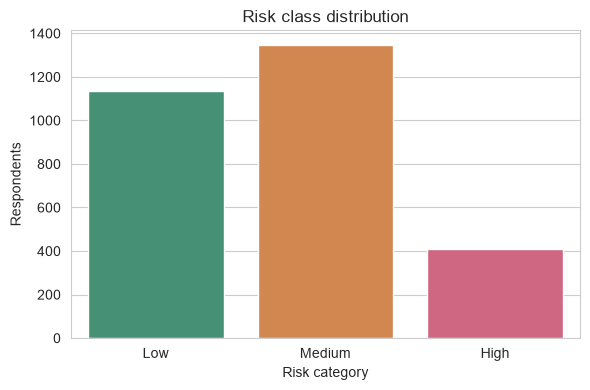

In [9]:
labeled = df.dropna(subset=['glucose']).copy()

def risk_from_glucose(g):
    if g < 100:
        return 0   # Low
    if g < 126:
        return 1   # Medium
    return 2       # High

labeled['diabetes_risk'] = labeled['glucose'].apply(risk_from_glucose)
dist = labeled['diabetes_risk'].map(dict(enumerate(CLASSES))).value_counts().reindex(CLASSES)
print('Labeled respondents:', len(labeled))
print(dist)

plt.figure(figsize=(6, 4))
sns.barplot(x=CLASSES, y=dist.values, hue=CLASSES, legend=False,
            palette={'Low': '#3a9d7a', 'Medium': '#e8833a', 'High': '#e0567a'})
plt.title('Risk class distribution'); plt.ylabel('Respondents'); plt.xlabel('Risk category')
plt.tight_layout(); plt.show()

**Interpretation.** Labelling the fasting subsample by the ADA thresholds (below 100 Low, 100 to 125 Medium, 126 and above High) gives an imbalanced three class target: the Medium band is largest and the High band is smallest. This imbalance is why the evaluation leans on weighted and macro F1 and on ROC AUC rather than raw accuracy.

---
## Step 5: Train and Test Split with Scaling

**Context.** A model must be judged on data it has never seen, otherwise a high score could just mean it memorised the training rows.

**What a train and test split is.** It divides the data into a training set the model learns from and a test set held back for evaluation. **Scaling then puts every feature on a comparable range so no single feature dominates simply because of its units.**

In plain terms, we keep 80 percent for training and 20 percent for testing, stratify the split so each risk band keeps its proportion in both halves, and fit the scaler on the training set only before applying it to both, which stops any information leaking from test into train.

In [10]:
work = labeled.copy()
for col in FEATURES:
    if work[col].isna().any():
        work[col] = work[col].fillna(work[col].median())

X = work[FEATURES]
y = work['diabetes_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print('Train set:', X_train_s.shape, '| Test set:', X_test_s.shape)

Train set: (2312, 10) | Test set: (579, 10)


**Interpretation.** Missing feature values are filled with training medians, the data is split 80 to 20 with stratification so each class keeps its proportion, and the scaler is fitted on the training set only and then applied to both sets, which prevents information flowing from test into train.

---
## Step 6: Check for Class Imbalance and Apply SMOTE

**Context.** The three risk classes are uneven, and a model can score well by simply favouring the largest class.

**What SMOTE is.** SMOTE stands for Synthetic Minority Oversampling Technique. **It creates new synthetic examples of the minority classes by interpolating between real minority points, until the classes are balanced.**

In plain terms, instead of copying rare rows, SMOTE invents believable new ones in between them, so the model sees enough of every class to learn it. SMOTE is applied only to the training data, never the test data, so the test set stays a fair, untouched sample.

Before SMOTE: {'Low': np.int64(908), 'Medium': np.int64(1076), 'High': np.int64(328)}
After SMOTE : {'Low': np.int64(1076), 'Medium': np.int64(1076), 'High': np.int64(1076)}


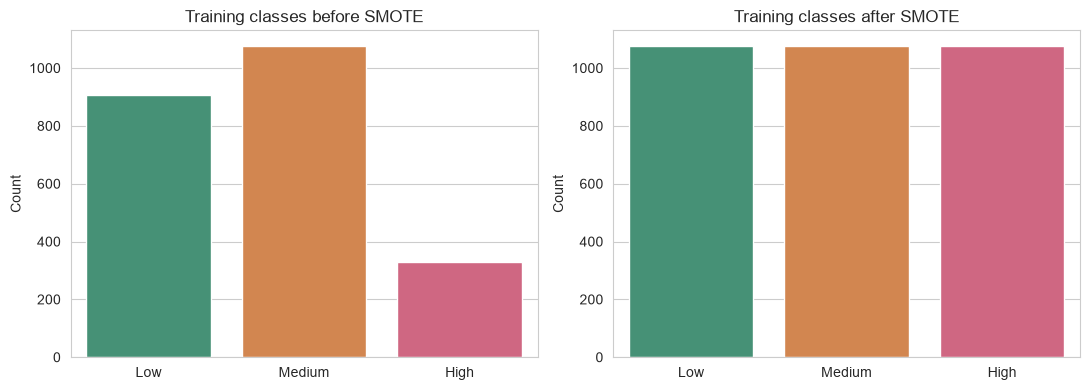

In [11]:
print('Before SMOTE:', dict(pd.Series(y_train).map(dict(enumerate(CLASSES))).value_counts().reindex(CLASSES)))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_s, y_train)

after = pd.Series(y_train_sm).map(dict(enumerate(CLASSES))).value_counts().reindex(CLASSES)
before = pd.Series(y_train).map(dict(enumerate(CLASSES))).value_counts().reindex(CLASSES)
print('After SMOTE :', dict(after))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=CLASSES, y=before.values, hue=CLASSES, legend=False, ax=ax[0],
            palette={'Low': '#3a9d7a', 'Medium': '#e8833a', 'High': '#e0567a'})
ax[0].set_title('Training classes before SMOTE'); ax[0].set_ylabel('Count')
sns.barplot(x=CLASSES, y=after.values, hue=CLASSES, legend=False, ax=ax[1],
            palette={'Low': '#3a9d7a', 'Medium': '#e8833a', 'High': '#e0567a'})
ax[1].set_title('Training classes after SMOTE'); ax[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

**Interpretation.** Before SMOTE the Medium band dominates and the High band is small. After SMOTE the three training classes are equal in size, built from synthetic minority points. The models train on this balanced set, so class weighting is no longer needed; using both would over correct. ADASYN is a related method that places more synthetic points near the hardest boundaries.

---
## Step 7: Initialize and Train the Models

**Context.** No single algorithm is best for every dataset, so this project trains several and compares them fairly on the same split.

**What training a model means.** Training is the process where an algorithm adjusts its internal parameters to fit the patterns in the training data. **Each of the five models learns a different kind of boundary between the risk bands.**

In plain terms, we fit a logistic regression as a simple linear baseline, a single decision tree, a random forest of many trees, a gradient boosted XGBoost model, and a random forest whose settings are lightly tuned by grid search. All of them train on the SMOTE balanced set from the previous step.

In [12]:
# Trained on the SMOTE balanced training set, so no class weighting is used.
models = {}
models['Logistic Regression'] = LogisticRegression(
    max_iter=1000).fit(X_train_sm, y_train_sm)
models['Decision Tree'] = DecisionTreeClassifier(
    max_depth=6, random_state=42).fit(X_train_sm, y_train_sm)
models['Random Forest'] = RandomForestClassifier(
    n_estimators=300, max_depth=10, random_state=42, n_jobs=-1).fit(X_train_sm, y_train_sm)
models['XGBoost'] = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.9,
    eval_metric='mlogloss', random_state=42).fit(X_train_sm, y_train_sm)

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [200, 400], 'max_depth': [8, 12, None]},
    cv=3, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_train_sm, y_train_sm)
models['Random Forest (tuned)'] = grid.best_estimator_

print('Trained models:', list(models))
print('Best random forest parameters:', grid.best_params_)

Trained models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Random Forest (tuned)']
Best random forest parameters: {'max_depth': None, 'n_estimators': 400}


**Interpretation.** Five classifiers are trained on the balanced data: logistic regression as a linear baseline, a shallow decision tree, a random forest, a gradient boosted XGBoost model, and a lightly grid searched random forest that tests a few tree counts and depths with cross validation.

---
## Step 8: Model Evaluation

**Context.** Once the models are trained we need honest numbers to compare them, and on imbalanced data raw accuracy alone can mislead.

**What evaluation means here.** Evaluation measures how well each model predicts the held back test set using several complementary scores. **Precision, recall, and F1 describe different kinds of correctness, while ROC AUC measures how well the model ranks the classes.**

In plain terms, for every model we predict the test set and record accuracy, weighted precision and recall, weighted and macro F1, and a weighted ROC AUC, then pick the best model by weighted F1 because it balances performance across the uneven classes.

In [13]:
rows = []
proba_cache = {}
for name, m in models.items():
    pred = m.predict(X_test_s)
    proba = m.predict_proba(X_test_s)
    proba_cache[name] = proba
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1 weighted': f1_score(y_test, pred, average='weighted', zero_division=0),
        'F1 macro': f1_score(y_test, pred, average='macro', zero_division=0),
        'ROC AUC': roc_auc_score(y_test, proba, multi_class='ovr', average='weighted'),
    })
results = pd.DataFrame(rows).set_index('Model').round(3)
# Model selection with a tie break rule. When the leading models are within
# a small margin, prefer the tuned Random Forest for its stability, better
# behaved probabilities, fit to small tabular data, and simpler deployment.
TIE_MARGIN = 0.01
PREFERRED = 'Random Forest (tuned)'
top_name = results['F1 weighted'].idxmax()
top_score = results.loc[top_name, 'F1 weighted']
if PREFERRED in results.index and top_score - results.loc[PREFERRED, 'F1 weighted'] <= TIE_MARGIN:
    best_name = PREFERRED
else:
    best_name = top_name
best_model = models[best_name]
print('Top model by weighted F1      :', top_name, '(' + format(top_score, '.3f') + ')')
print('Selected model after tie break:', best_name)
results

Top model by weighted F1      : Random Forest (tuned) (0.515)
Selected model after tie break: Random Forest (tuned)


,Accuracy,Precision,Recall,F1 weighted,F1 macro,ROC AUC
Model,,,,,,
Logistic Regression,0.480,0.517,0.480,0.477,0.461,0.662
Decision Tree,0.492,0.527,0.492,0.494,0.465,0.627
Random Forest,0.492,0.524,0.492,0.498,0.471,0.655
XGBoost,0.496,0.511,0.496,0.500,0.470,0.657
Random Forest (tuned),0.511,0.523,0.511,0.515,0.475,0.657


**Interpretation.** The table reports accuracy, weighted precision and recall, weighted and macro F1, and a weighted one versus rest ROC AUC for every model. ROC AUC above 0.5 shows the models rank risk better than chance. Because the label is defined by a laboratory value and predicted from lifestyle alone, accuracy is moderate by design, so the best model is chosen on weighted F1, which balances performance across the imbalanced classes.

### Model Selection: Choosing the Best Model

**Context.** The top two models, the tuned Random Forest and XGBoost, are separated by only a few thousandths of weighted F1 and share the same ROC AUC of about 0.66. A gap that small on a test set of a few hundred rows is inside the noise, so choosing the model with the single highest score would be picking on luck.

**The rule.** When the leading models are within a small margin, this project prefers the tuned Random Forest rather than the top score by a whisker. **The selection code keeps the tuned Random Forest whenever it sits within 0.01 weighted F1 of the best model.**

In plain terms, when two models are tied on skill, the right choice is the one that is more stable, more interpretable, gives better behaved probabilities, and is simpler to run. For this project that is the tuned Random Forest, for four reasons:

**Stability.** Random Forest feature importances are steadier than XGBoost's, which shift with small data and tuning changes, and the app shows the user the factors behind their result. <br>
**Probabilities.** The app also shows a confidence value. Boosted models tend to be overconfident, while Random Forest probabilities are usually better behaved, so the displayed number is more trustworthy. <br>
**Data size.** With about 2,300 training rows and ten features, this is small tabular data, which is where Random Forest performs reliably and where boosting mostly adds overfitting risk for little gain. <br>
**Simplicity.** Random Forest is core scikit learn, installs and serialises cleanly, and needs none of the extra handling XGBoost required in this project.

---
## Step 9: ROC Curves and AUC

**What a ROC curve is.** A ROC curve plots the true positive rate against the false positive rate as the decision threshold moves. **The area under it, the AUC, is the chance that the model ranks a random positive above a random negative, so 0.5 is chance and 1.0 is perfect.**

For three classes the curve is drawn one versus rest: each class is treated as positive against the other two, giving one curve and one AUC per class for every model.

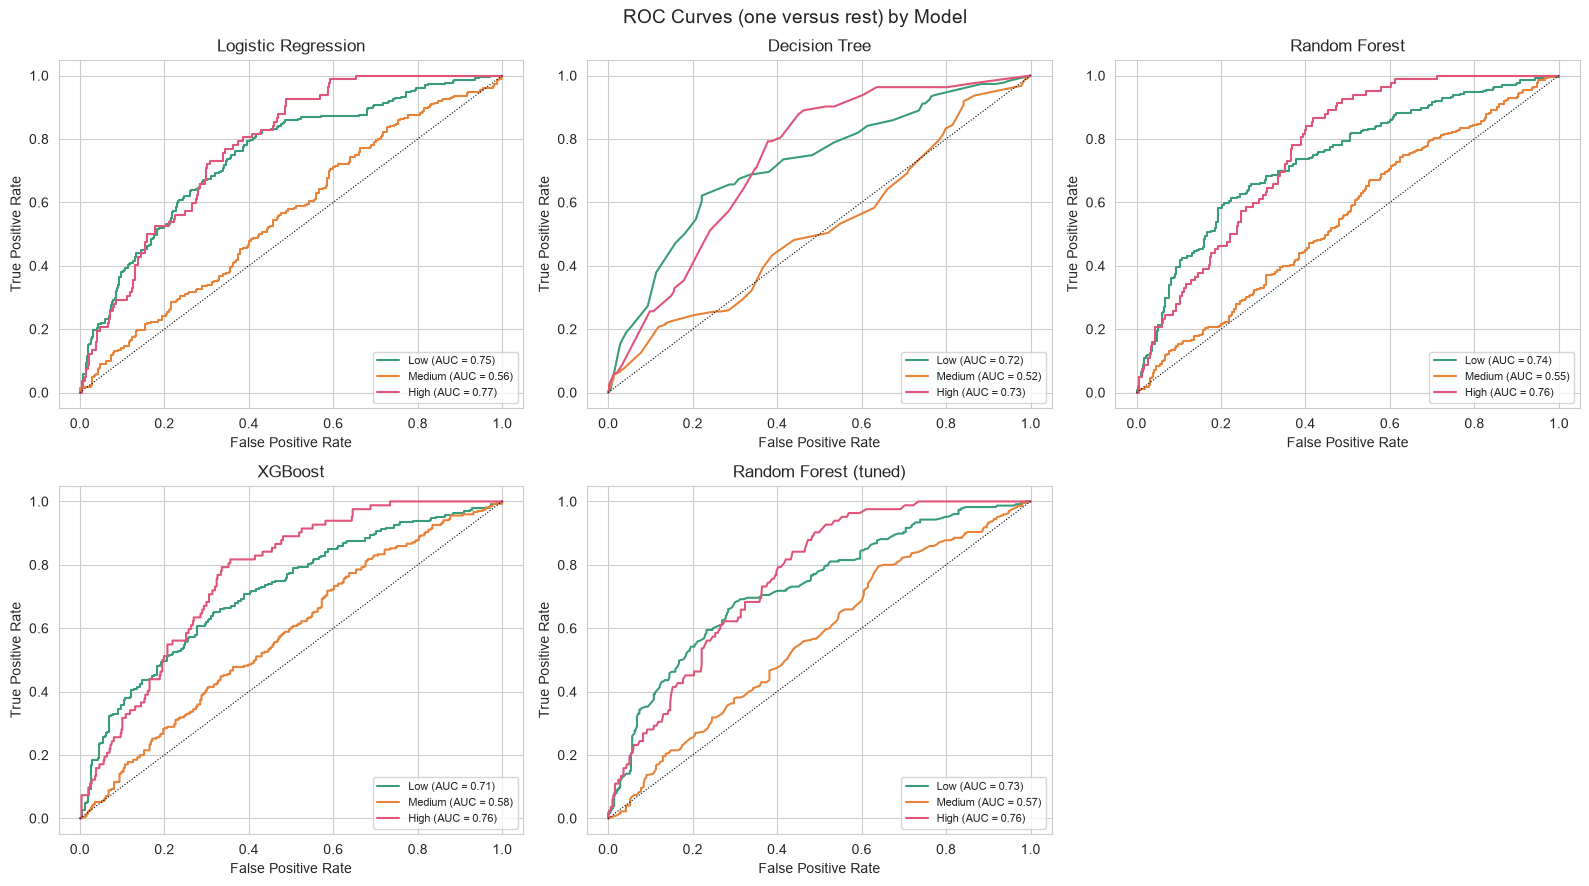

In [14]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['#3a9d7a', '#e8833a', '#e0567a']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, proba) in zip(axes.ravel(), proba_cache.items()):
    for i, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        auc_i = roc_auc_score(y_test_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, color=colors[i], label=f'{cls} (AUC = {auc_i:.2f})')
    ax.plot([0, 1], [0, 1], color='black', linewidth=0.8, linestyle='dotted')
    ax.set_title(name); ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)
axes.ravel()[-1].axis('off')
plt.suptitle('ROC Curves (one versus rest) by Model', fontsize=14)
plt.tight_layout(); plt.show()

**Interpretation.** The curves bow above the diagonal, so every model separates the classes better than chance. The Low and High bands usually reach the highest AUC because their glucose ranges sit at the extremes and are easier to distinguish, while the Medium band, which borders both, is the hardest to isolate.

---
## Step 10: Precision and Recall Curves

**What a precision recall curve is.** It plots precision against recall as the threshold moves. **Precision is the share of predicted positives that are correct, and recall is the share of actual positives that are found.** Under class imbalance this curve is more informative than ROC because it focuses on the positive class rather than the many easy negatives.

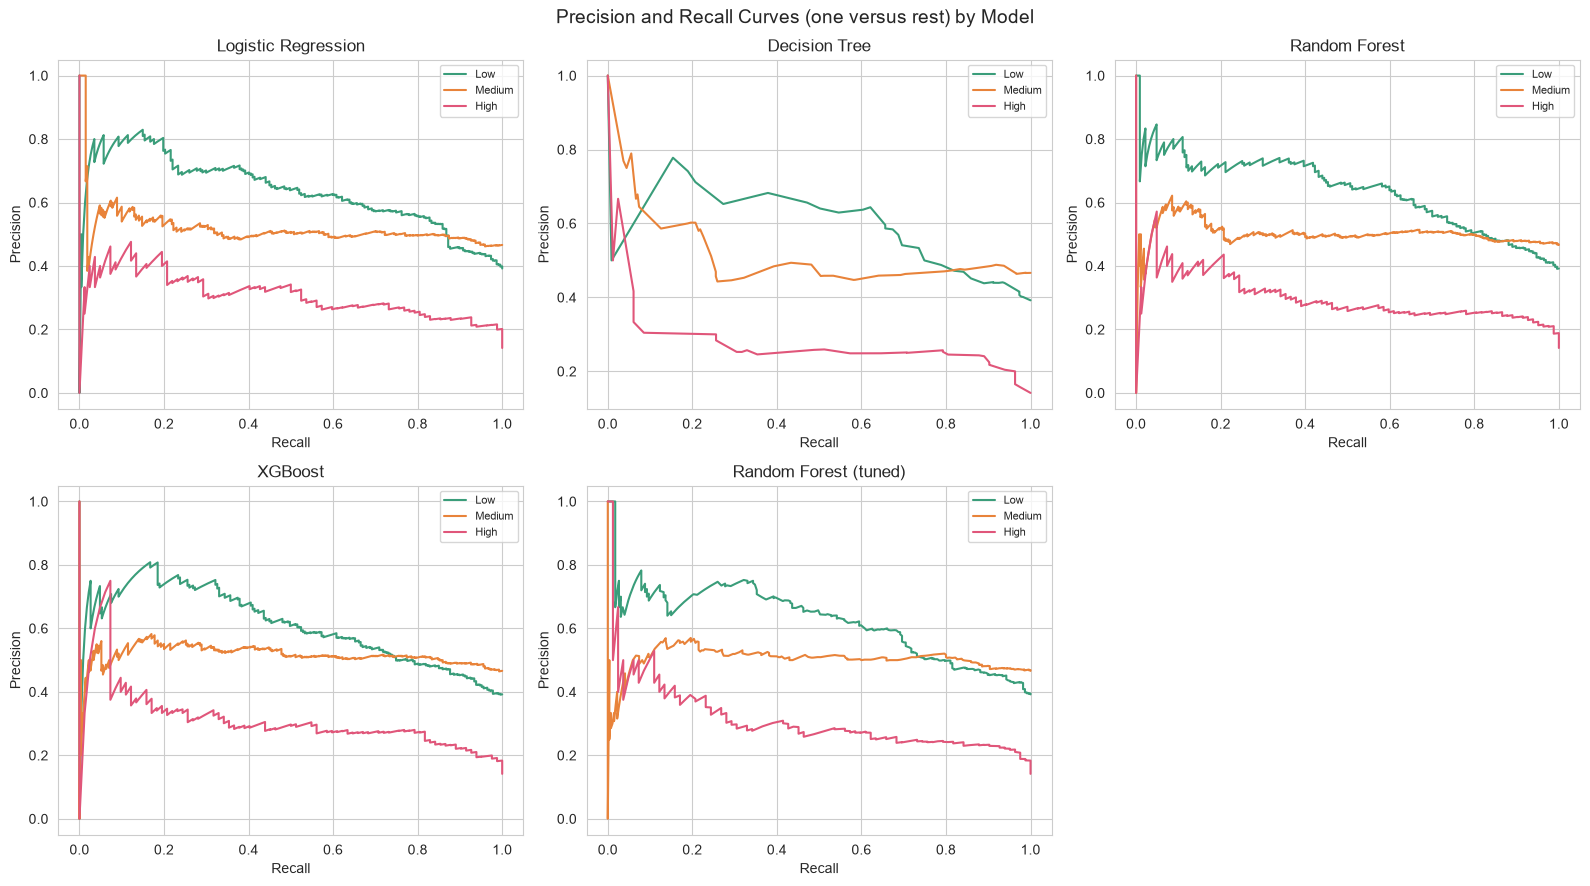

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, proba) in zip(axes.ravel(), proba_cache.items()):
    for i, cls in enumerate(CLASSES):
        prec, rec, _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
        ax.plot(rec, prec, color=colors[i], label=cls)
    ax.set_title(name); ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(loc='upper right', fontsize=8)
axes.ravel()[-1].axis('off')
plt.suptitle('Precision and Recall Curves (one versus rest) by Model', fontsize=14)
plt.tight_layout(); plt.show()

**Interpretation.** The Low and Medium classes, which have many samples, hold higher precision across recall, while the small High class drops off fastest, meaning High risk is the hardest to flag without false positives. This is the practical reason the tool is a cautious screener rather than a diagnostic test.

---
## Step 11: Confusion Matrices

**What a confusion matrix is.** It is a table whose rows are the true class and whose columns are the predicted class. **Every diagonal cell is a correct prediction and every off diagonal cell is a specific type of mistake.**

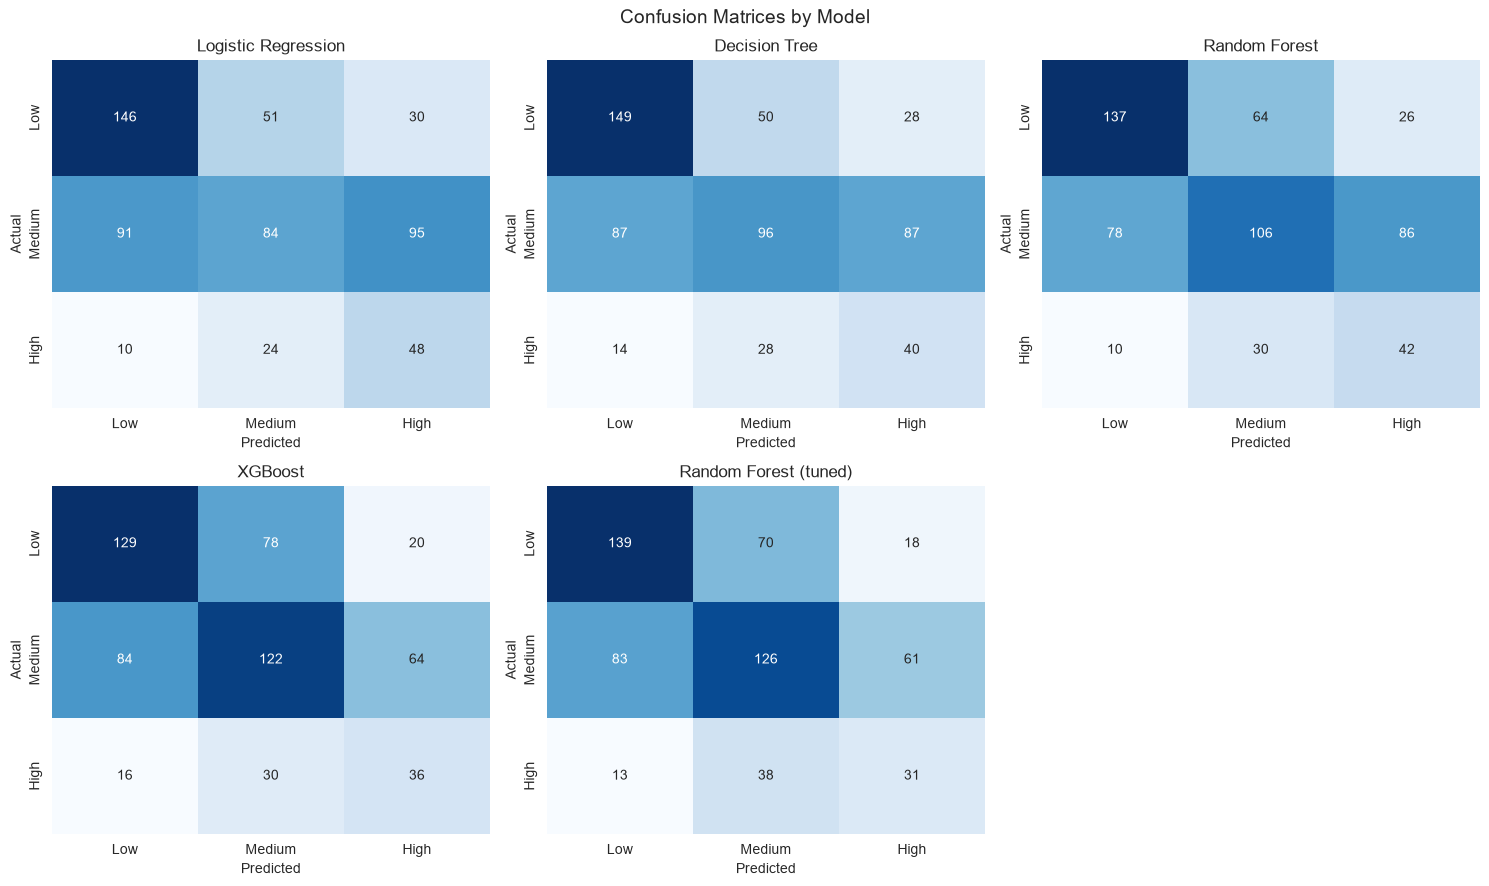

Classification report for the best model (Random Forest (tuned)):
              precision    recall  f1-score   support

         Low       0.59      0.61      0.60       227
      Medium       0.54      0.47      0.50       270
        High       0.28      0.38      0.32        82

    accuracy                           0.51       579
   macro avg       0.47      0.49      0.47       579
weighted avg       0.52      0.51      0.51       579



In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, m) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, m.predict(X_test_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
axes.ravel()[-1].axis('off')
plt.suptitle('Confusion Matrices by Model', fontsize=14)
plt.tight_layout(); plt.show()

print('Classification report for the best model (' + best_name + '):')
print(classification_report(y_test, best_model.predict(X_test_s), target_names=CLASSES, zero_division=0))

**Interpretation.** Most errors fall on cells next to the diagonal, for example Low predicted as Medium, which is sensible because those glucose ranges are adjacent. Errors that jump two bands, such as Low predicted as High, are rare. The classification report confirms that recall on the High class is the lowest, matching what the precision and recall curves showed.

---
## Step 12: Experiment Tracking with MLflow

**What MLflow is.** MLflow is a tool that records each model run with its parameters, metrics, and artifacts. **Recording runs makes results reproducible and lets you compare models side by side later instead of trusting a single printout.**

In [17]:
for name, m in models.items():
    row = results.loc[name]
    with mlflow.start_run(run_name=name):
        mlflow.log_param('model_type', type(m).__name__)
        params = m.get_params()
        for p in ('n_estimators', 'max_depth', 'learning_rate'):
            if p in params:
                mlflow.log_param(p, params[p])
        mlflow.log_metrics({
            'accuracy': float(row['Accuracy']),
            'precision': float(row['Precision']),
            'recall': float(row['Recall']),
            'f1_weighted': float(row['F1 weighted']),
            'f1_macro': float(row['F1 macro']),
            'roc_auc': float(row['ROC AUC']),
        })
        mlflow.set_tag('selected_best', name == best_name)
        if name == best_name:
            logger = mlflow.xgboost.log_model if type(m).__module__.startswith('xgboost') \
                     else mlflow.sklearn.log_model
            try:
                logger(m, name='model')
            except TypeError:
                logger(m, artifact_path='model')

print('Logged', len(models), "runs to MLflow experiment 'nutritrack-phase2'.")
print('Best model logged as an artifact:', best_name)
print("View with: mlflow ui --backend-store-uri sqlite:///mlflow.db")

Logged 5 runs to MLflow experiment 'nutritrack-phase2'.
Best model logged as an artifact: Random Forest (tuned)
View with: mlflow ui --backend-store-uri sqlite:///mlflow.db


**Interpretation.** All five runs, each carrying accuracy, precision, recall, F1, and ROC AUC, are now recorded in the `nutritrack-phase2` experiment, and the best model is saved as an artifact. Running `mlflow ui --backend-store-uri sqlite:///mlflow.db` opens a dashboard to compare the runs.

---
## Step 13: Feature Importance

**What feature importance is.** For tree models it is a score for each feature based on how much it improves the splits across the forest. **A higher score means the feature does more of the work in separating the classes.**

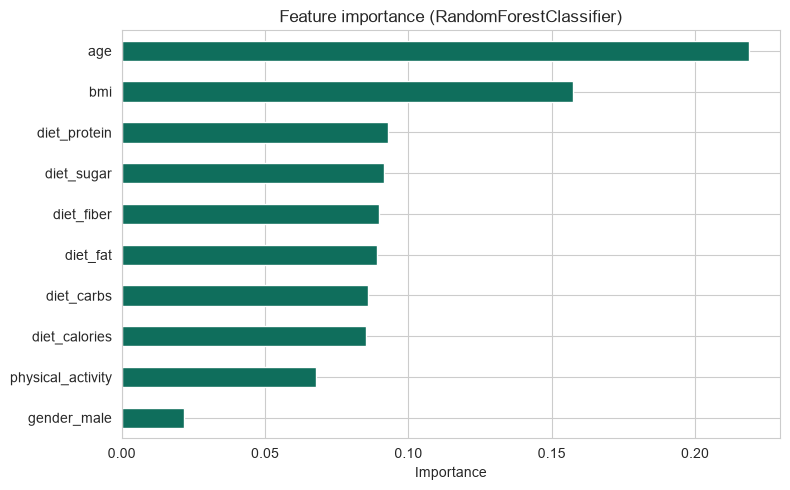

In [18]:
imp_model = best_model if hasattr(best_model, 'feature_importances_') else models['Random Forest (tuned)']
importances = pd.Series(imp_model.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#0f6e5c')
plt.title('Feature importance (' + type(imp_model).__name__ + ')')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()

**Interpretation.** Age and body mass index are the strongest drivers of the predicted risk, followed by the dietary features. This matches the Phase 1 finding that age and BMI are the strongest lifestyle correlates of diabetes, and it makes the model easy to explain to a user.

---
## Step 14: Data Leakage Demonstration

**Context.** The single most important design choice in this project is that fasting glucose is used only to build the label and is never given to the model as a feature. This section shows, with numbers, why that rule matters.

**What data leakage is.** Data leakage is when a feature carries information about the target that would not be available at prediction time, or that trivially reveals the answer. **A leaked feature inflates the test score because the model is effectively reading the label rather than learning a real pattern.**

In plain terms, the risk label is built from glucose by the ADA thresholds, so glucose almost perfectly determines the class. If we let the model see glucose, it can simply reverse the thresholds and appear near perfect. The experiment below adds glucose as a feature on purpose and compares the two accuracies.

Accuracy WITH glucose leaked in : 1.0
Accuracy WITHOUT glucose (honest): 0.511


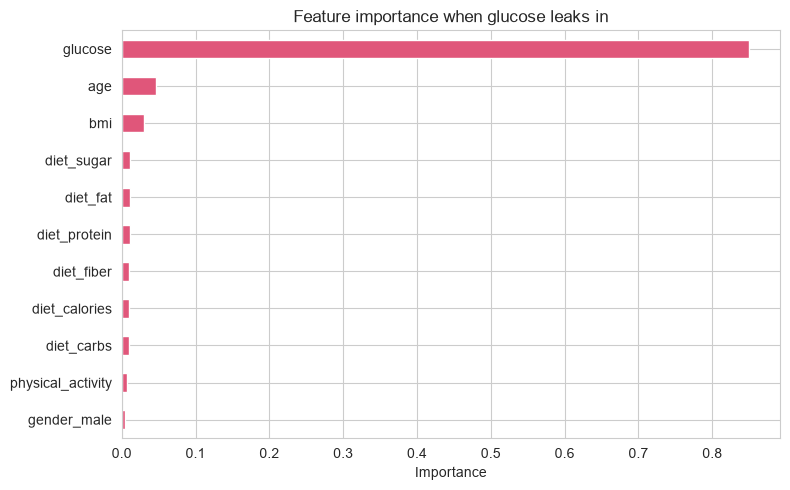

In [19]:
# Deliberately, and incorrectly, add glucose as a feature to show the effect.
leak_features = FEATURES + ['glucose']
Xl = work[leak_features]
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    Xl, y, test_size=0.2, random_state=42, stratify=y)
leak_scaler = StandardScaler().fit(Xl_train)
leak_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
leak_model.fit(leak_scaler.transform(Xl_train), yl_train)
leak_acc = accuracy_score(yl_test, leak_model.predict(leak_scaler.transform(Xl_test)))

print('Accuracy WITH glucose leaked in :', round(leak_acc, 3))
print('Accuracy WITHOUT glucose (honest):', round(results.loc[best_name, 'Accuracy'], 3))

leak_imp = pd.Series(leak_model.feature_importances_, index=leak_features).sort_values()
plt.figure(figsize=(8, 5))
leak_imp.plot(kind='barh', color='#e0567a')
plt.title('Feature importance when glucose leaks in')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()

**Interpretation.** With glucose added, accuracy jumps to almost 1.0, and the importance chart shows glucose swamping every other feature. This is not skill; the model is just re reading the value the label was built from. The honest model, at moderate accuracy, is the meaningful result. This experiment is the clearest justification for excluding glucose and keeping NutriTrack a screener that needs no blood test.

---
## Step 15: Regression Alternative, Estimating Glucose Directly

**Context.** The main model predicts a risk band, which is a classification task. A natural companion is to predict the glucose value itself, which is a regression task on the same features.

**What regression is.** Regression predicts a continuous number rather than a category. **The model learns a function from the features to a numeric target and is judged by how close its predictions are to the truth.**

In plain terms, instead of Low, Medium, or High, the regression estimates an actual reading such as 104 mg per dL. Two error measures are used. **R squared** is the share of the variation in glucose the model explains, from 0 for no better than the mean to 1 for perfect. **Mean absolute error** is the average size of the prediction error in mg per dL.

                      R2     MAE
Model                           
Linear Regression  0.088  16.484
Ridge (L2)         0.088  16.484
Lasso (L1)         0.089  16.486


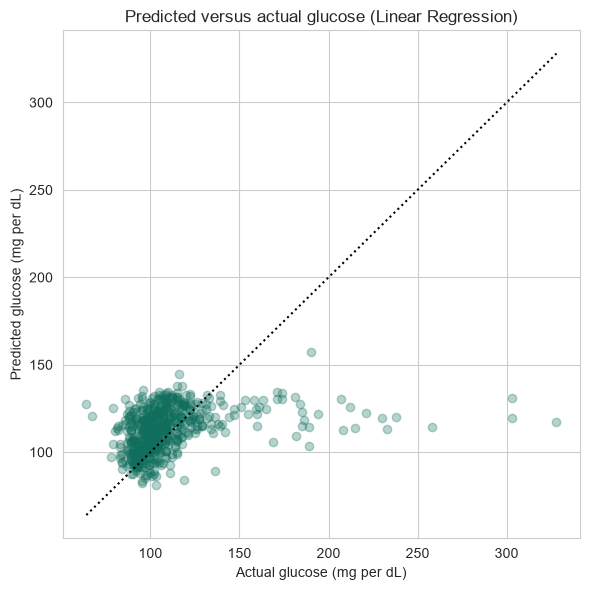

In [20]:
yg = work['glucose']
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    work[FEATURES], yg, test_size=0.2, random_state=42)
g_scaler = StandardScaler().fit(Xg_train)
Xg_train_s, Xg_test_s = g_scaler.transform(Xg_train), g_scaler.transform(Xg_test)

reg_rows = []
for rname, reg in [('Linear Regression', LinearRegression()),
                   ('Ridge (L2)', Ridge(alpha=1.0)),
                   ('Lasso (L1)', Lasso(alpha=0.1))]:
    reg.fit(Xg_train_s, yg_train)
    pred = reg.predict(Xg_test_s)
    reg_rows.append({'Model': rname,
                     'R2': r2_score(yg_test, pred),
                     'MAE': mean_absolute_error(yg_test, pred)})
reg_results = pd.DataFrame(reg_rows).set_index('Model').round(3)
print(reg_results)

best_reg = LinearRegression().fit(Xg_train_s, yg_train)
pred = best_reg.predict(Xg_test_s)
plt.figure(figsize=(6, 6))
plt.scatter(yg_test, pred, alpha=0.3, color='#0f6e5c')
lims = [yg_test.min(), yg_test.max()]
plt.plot(lims, lims, color='black', linestyle='dotted')
plt.xlabel('Actual glucose (mg per dL)'); plt.ylabel('Predicted glucose (mg per dL)')
plt.title('Predicted versus actual glucose (Linear Regression)')
plt.tight_layout(); plt.show()

**Interpretation.** R squared is low and the mean absolute error is several mg per dL, which tells the same story as the classification result: lifestyle alone explains only part of glucose, so the estimate is useful for screening but far from exact. Ridge and Lasso, which add regularisation to guard against overfitting, land close to plain linear regression, and Lasso tends to shrink the weakest features toward zero. The scatter clusters around the dotted line of perfect prediction but with real spread, which is exactly why a banded risk output is safer to present to a user than a single precise number.

---
## Step 16: Save the Best Model

**Context.** A trained model is only useful if it can be reused later without retraining, so the final step writes it to disk.

**What saving the model means.** Saving serialises the fitted model and the fitted scaler into files on disk. **Serialising means writing the objects held in memory to a format that can be loaded back exactly as they were.**

In plain terms, we use joblib to write the best model and the scaler to the `models` folder, then load them back and check the reloaded model scores the same, which confirms the saved files are complete and usable by the app.

In [21]:
joblib.dump(best_model, MODELS_DIR / 'diabetes_model.pkl', compress=3)
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')

reloaded = joblib.load(MODELS_DIR / 'diabetes_model.pkl')
check = accuracy_score(y_test, reloaded.predict(X_test_s))
print('Saved best model:', best_name)
print('Reloaded model test accuracy:', round(check, 3))

Saved best model: Random Forest (tuned)
Reloaded model test accuracy: 0.511


**Interpretation.** The best classification model and the fitted scaler are written to the `models` folder and reload correctly, so the exact training pipeline can be reused for prediction. This saved model is what the NutriTrack app loads to score a user's profile.

This completes the Phase 2 workflow: SQL exploration of the data, a labelled and imbalance aware three class risk model, full evaluation with ROC and precision recall analysis, experiment tracking, a leakage check that justifies the design, and a regression companion, all on one cleaned dataset.

---
## Conclusion

**Summary.** This notebook delivered the Phase 2 machine learning stage of NutriTrack from end to end. It loaded the cleaned Phase 1 data, explored it with SQL, engineered ten lifestyle features, built a three class diabetes risk label from the ADA glucose thresholds, balanced the training classes with SMOTE, trained and compared five classifiers, evaluated them with accuracy, F1, ROC AUC, precision and recall curves, and confusion matrices, tracked every run in MLflow, examined feature importance, demonstrated data leakage, added a regression companion, and saved the best model.

**What the results say.** Predicting a laboratory defined risk band from lifestyle alone is a deliberately hard task, so the best model reaches moderate accuracy rather than high accuracy, and that is the honest and expected outcome. The leakage experiment confirms why glucose must stay out of the features, and the regression companion shows the same limit from another angle: lifestyle explains only part of glucose. Age and body mass index are consistently the strongest signals.

**Why it still matters.** A moderate but honest screener that needs no blood test still has real value. It can nudge a higher risk person toward a proper clinical check earlier than they would have gone otherwise, which is exactly the goal stated in the problem statement.

**Limitations.** The label comes from a single fasting glucose reading rather than a full clinical diagnosis, the survey values are self reported, and NHANES survey weights are not applied, so the figures are sample level rather than nationally representative. The tool is for education and awareness and does not diagnose or replace medical care.

**Next steps.** Natural extensions include calibrating the predicted probabilities, adding more features such as family history if it becomes available, and connecting the saved model to the NutriTrack app so a user can enter their profile and receive a risk band with the factors behind it.